<a href="https://colab.research.google.com/github/Geethanjali295/ML-PROJECT/blob/main/NEW_project_crop2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
df=pd.read_csv('/content/crop_yield.csv')
df

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251
...,...,...,...,...,...,...,...,...,...,...
999995,West,Silt,Rice,302.805345,27.987428,False,False,Sunny,76,1.347586
999996,South,Chalky,Barley,932.991383,39.661039,True,False,Rainy,93,7.311594
999997,North,Peaty,Cotton,867.362046,24.370042,True,False,Cloudy,108,5.763182
999998,West,Silt,Wheat,492.812857,33.045505,False,False,Sunny,102,2.070159


In [ ]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


In [ ]:
df.isnull().sum()

,0
Region,0
Soil_Type,0
Crop,0
Rainfall_mm,1
Temperature_Celsius,1
Fertilizer_Used,1
Irrigation_Used,1
Weather_Condition,1
Days_to_Harvest,1
Yield_tons_per_hectare,1


In [ ]:
df['Days_to_Harvest'] = df['Days_to_Harvest'].fillna(df['Days_to_Harvest'].mean())
df['Yield_tons_per_hectare'] = df['Yield_tons_per_hectare'].fillna(df['Yield_tons_per_hectare'].mean())
df['Temperature_Celsius'] = df['Temperature_Celsius'].fillna(df['Temperature_Celsius'].mean())
df['Weather_Condition'] = df['Weather_Condition'].fillna(df['Weather_Condition'].mode()[0])
df['Irrigation_Used'] = df['Irrigation_Used'].fillna(df['Irrigation_Used'].mode()[0])
df['Fertilizer_Used'] = df['Fertilizer_Used'].fillna(df['Fertilizer_Used'].mode()[0])
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].mean())

/tmp/ipykernel_239/2421157451.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Irrigation_Used'] = df['Irrigation_Used'].fillna(df['Irrigation_Used'].mode()[0])
/tmp/ipykernel_239/2421157451.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Fertilizer_Used'] = df['Fertilizer_Used'].fillna(df['Fertilizer_Used'].mode()[0])


In [4]:
df.isnull().sum()

,0
Region,0
Soil_Type,0
Crop,0
Rainfall_mm,0
Temperature_Celsius,0
Fertilizer_Used,0
Irrigation_Used,0
Weather_Condition,0
Days_to_Harvest,0
Yield_tons_per_hectare,0


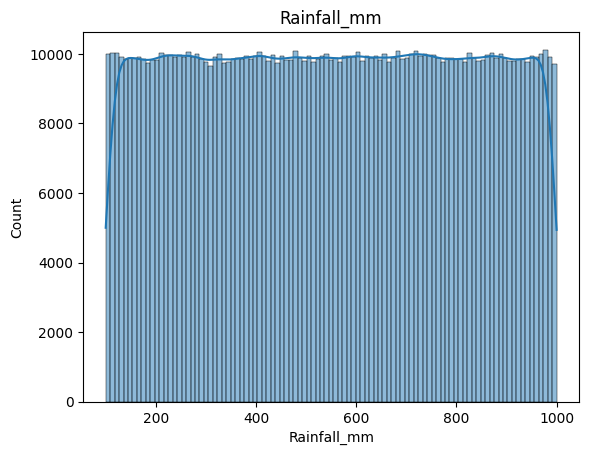

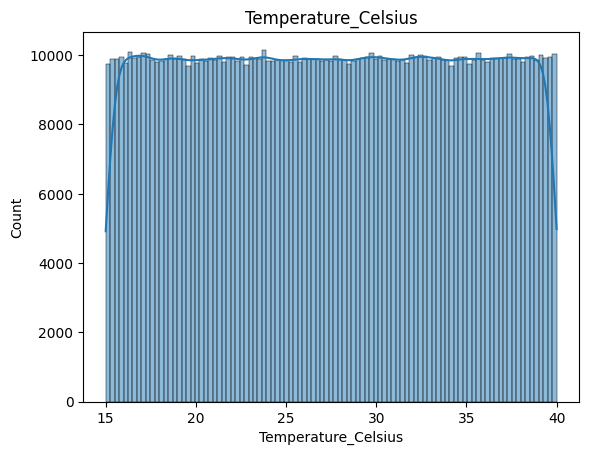

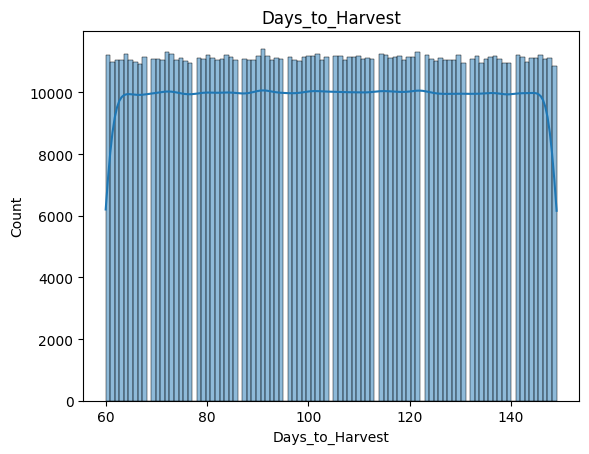

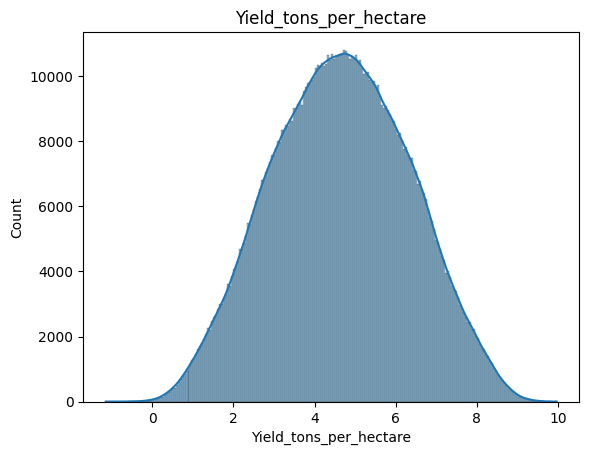

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.histplot(df[col],kde=True)
  plt.title(col)
  plt.show()

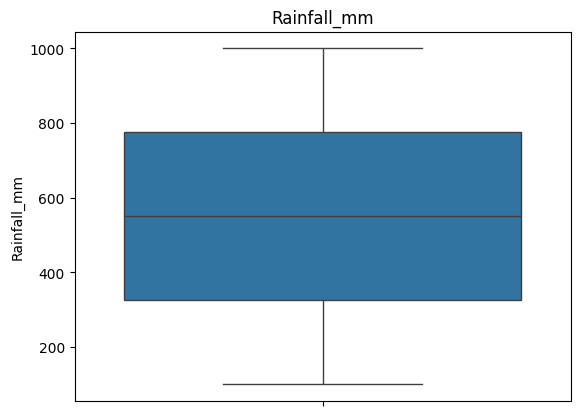

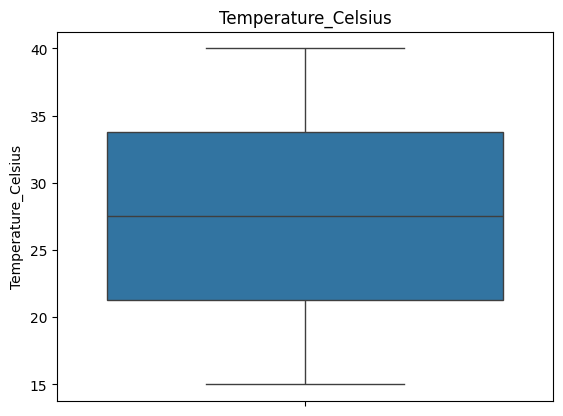

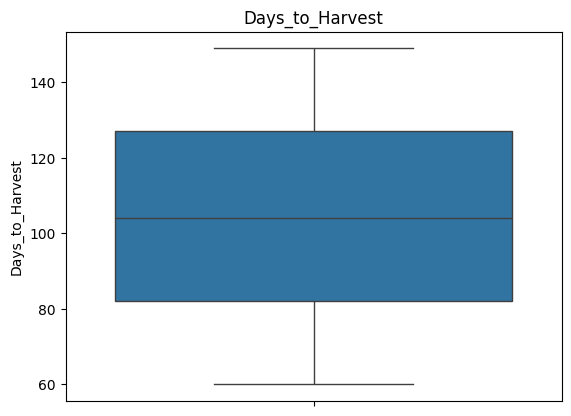

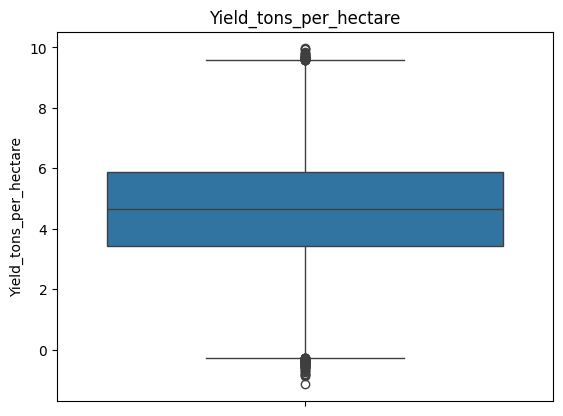

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

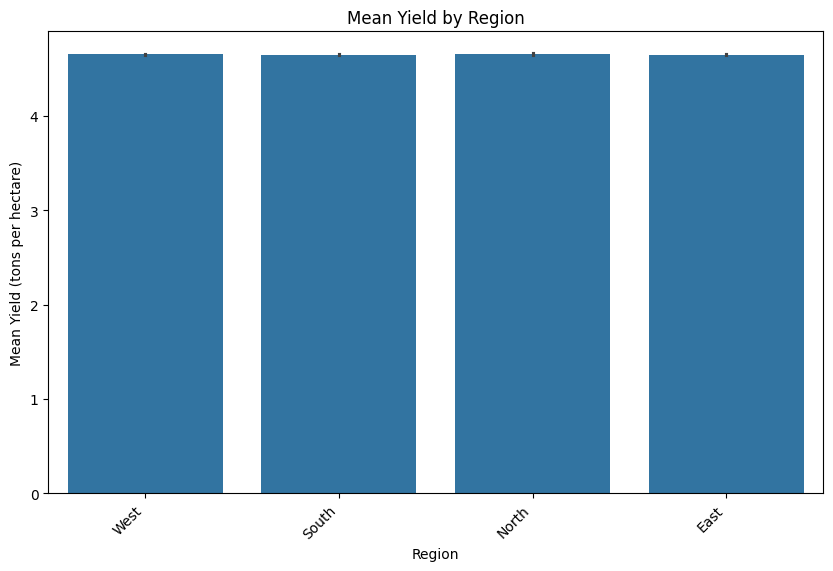

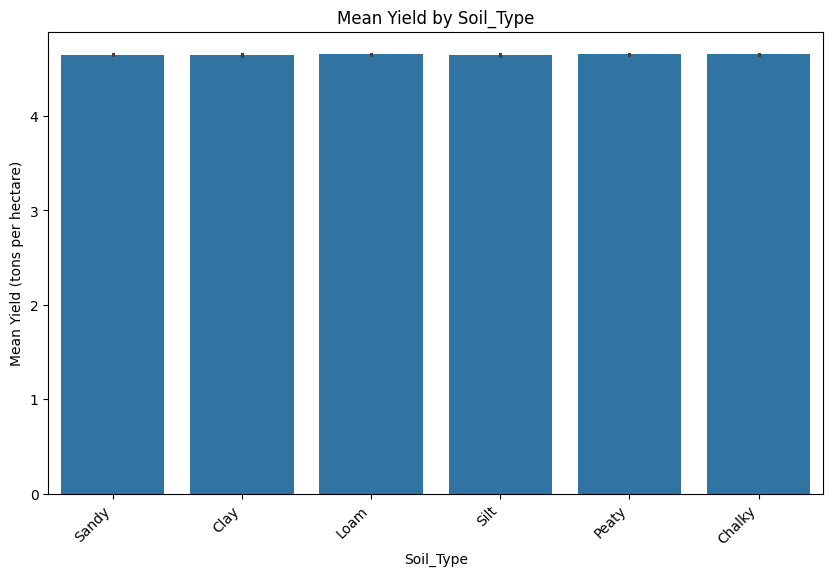

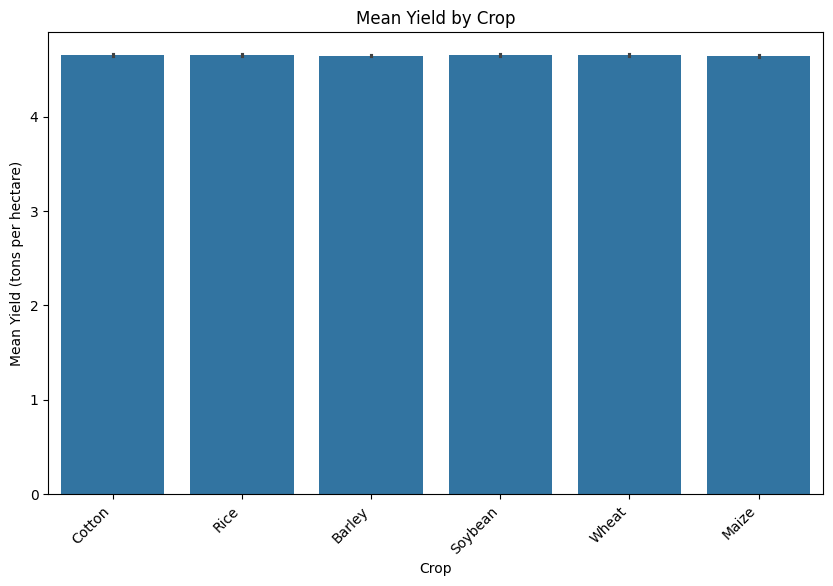

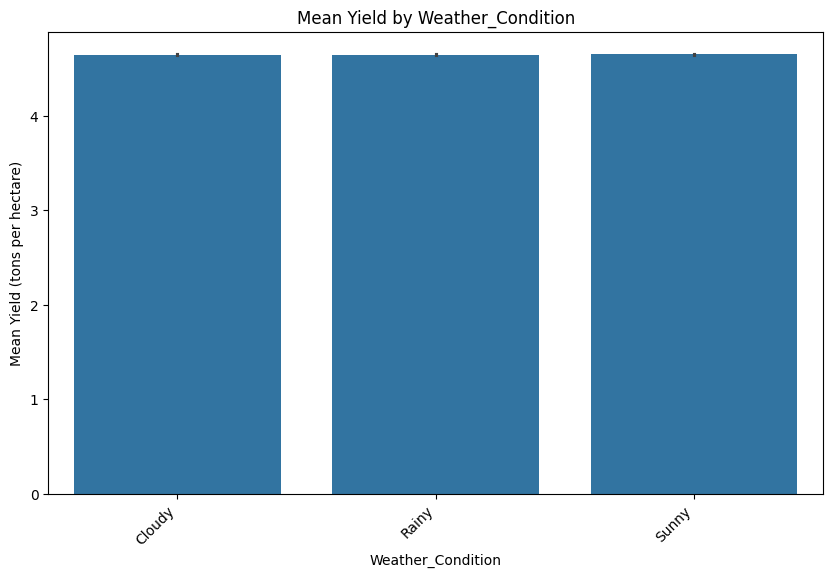

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=col, y='Yield_tons_per_hectare', data=df)
    plt.title(f'Mean Yield by {col}')
    plt.xlabel(col)
    plt.ylabel('Mean Yield (tons per hectare)')
    plt.xticks(rotation=45, ha='right')
    plt.show()

In [ ]:
from scipy.stats import skew
for col in numerical_cols:
  print(col)
  print(skew(df[col]))

Rainfall_mm
-0.00023170416261707546
Temperature_Celsius
-0.0008819979698115169
Days_to_Harvest
0.007144312396269119
Yield_tons_per_hectare
-0.0026248804798038997


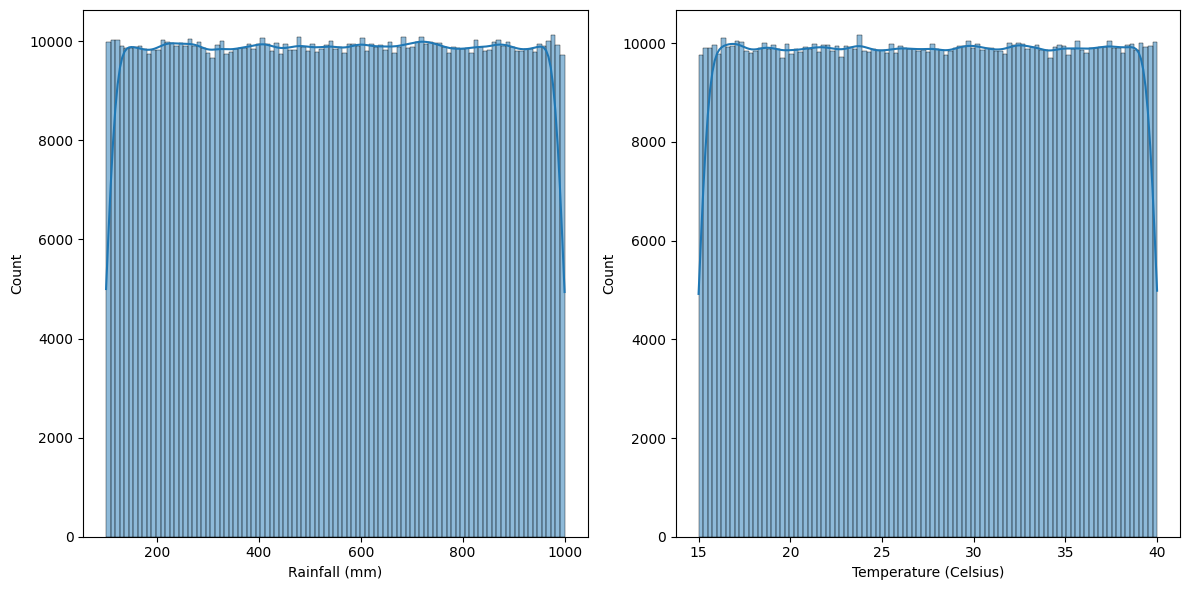

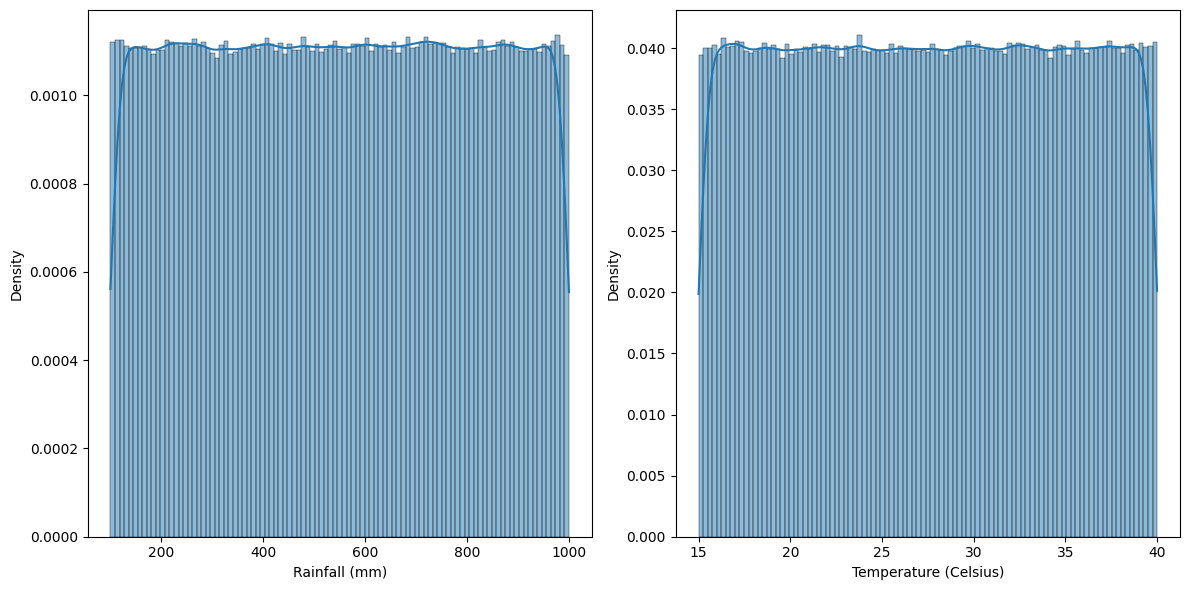

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['Rainfall_mm'], kde=True)
plt.xlabel('Rainfall (mm)')
plt.ylabel('Count')

# Original histplot showing counts for Temperature_Celsius
plt.subplot(1, 2, 2)
sns.histplot(df['Temperature_Celsius'], kde=True)
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Normalized histplot showing density for Rainfall_mm
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['Rainfall_mm'], kde=True, stat='density')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Density')

# Normalized histplot showing density for Temperature_Celsius
plt.subplot(1, 2, 2)
sns.histplot(df['Temperature_Celsius'], kde=True, stat='density')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

<Axes: >

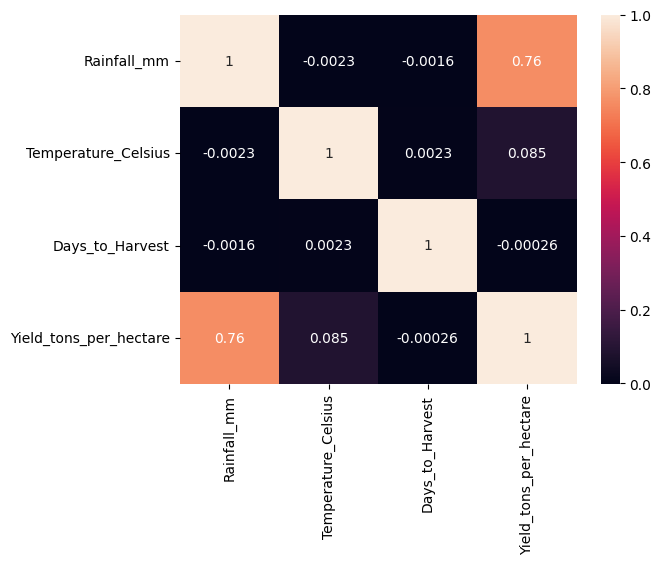

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True)

In [ ]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm # Correct import for anova_lm

categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

for col in categorical_cols:
    print(f"\n--- ANOVA for {col} and Yield_tons_per_hectare ---")

    formula = f'Yield_tons_per_hectare ~ C({col})'

    # Fit the OLS model (which is the basis for ANOVA in statsmodels)
    model = smf.ols(formula, data=df).fit()

    # Perform ANOVA
    anova_table = anova_lm(model, typ=2) # Use the correctly imported anova_lm

    print(anova_table)



--- ANOVA for Region and Yield_tons_per_hectare ---
                 sum_sq        df        F    PR(>F)
C(Region)  9.248421e+00       3.0  1.07103  0.359924
Residual   2.878346e+06  999996.0      NaN       NaN

--- ANOVA for Soil_Type and Yield_tons_per_hectare ---
                    sum_sq        df         F    PR(>F)
C(Soil_Type)  6.625494e+00       5.0  0.460365  0.805999
Residual      2.878349e+06  999994.0       NaN       NaN

--- ANOVA for Crop and Yield_tons_per_hectare ---
                sum_sq        df         F   PR(>F)
C(Crop)   1.697082e+01       5.0  1.179202  0.31647
Residual  2.878338e+06  999994.0       NaN      NaN

--- ANOVA for Weather_Condition and Yield_tons_per_hectare ---
                            sum_sq        df         F    PR(>F)
C(Weather_Condition)  3.706569e+00       2.0  0.643868  0.525257
Residual              2.878351e+06  999997.0       NaN       NaN


In [ ]:
# Drop any rows with NaN values to ensure clean data for analysis
df = df.dropna()
print(f"DataFrame shape after dropping NaN: {df.shape}")

DataFrame shape after dropping NaN: (1000000, 10)


In [ ]:
# Interpret the p-value
p_value = anova_table['PR(>F)'].iloc[0]
if p_value < 0.05:
    print(f"Conclusion: There is a significant relationship between {col} and Yield_tons_per_hectare (p={p_value:.4f})")
else:
    print(f"Conclusion: No significant relationship between {col} and Yield_tons_per_hectare (p={p_value:.4f})")

Conclusion: No significant relationship between Weather_Condition and Yield_tons_per_hectare (p=0.4383)


In [ ]:
from scipy.stats import f_oneway

categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

for col in categorical_cols:
    print(f"\n--- ANOVA for {col} and Yield_tons_per_hectare ---")

    # Prepare groups, ensuring no NaN and at least 2 groups
    groups = [df[df[col] == val]['Yield_tons_per_hectare'].dropna() for val in df[col].unique() if len(df[df[col] == val].dropna()) > 1]

    if len(groups) < 2:
        print(f"Skipping {col}: not enough valid groups")
        continue

    # Perform one-way ANOVA
    f_stat, p_val = f_oneway(*groups)

    print(f"F-statistic: {f_stat}")
    print(f"P-value: {p_val}")



--- ANOVA for Region and Yield_tons_per_hectare ---
F-statistic: 1.0710298955795718
P-value: 0.35992377022524275

--- ANOVA for Soil_Type and Yield_tons_per_hectare ---
F-statistic: 0.460364974118186
P-value: 0.8059986906243686

--- ANOVA for Crop and Yield_tons_per_hectare ---
F-statistic: 1.1792023335340958
P-value: 0.3164701789417449

--- ANOVA for Weather_Condition and Yield_tons_per_hectare ---
F-statistic: 0.6438681672130914
P-value: 0.5252569266777116


In [5]:
df = df.drop(columns=['Region'])
print("DataFrame after dropping 'Region' column:")
display(df.head())

DataFrame after dropping 'Region' column:


,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [7]:
df[['Rainfall_mm', 'Temperature_Celsius']] = scaler.fit_transform(df[['Rainfall_mm', 'Temperature_Celsius']])

print("DataFrame after targeted standardization and preprocessing:")
display(df.head())

DataFrame after targeted standardization and preprocessing:


,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,Sandy,Cotton,1.335747,0.023821,False,True,Cloudy,122,6.555816
1,Clay,Rice,1.703634,-1.312747,True,True,Rainy,140,8.527341
2,Loam,Barley,-1.546977,0.317020,False,False,Sunny,106,1.127443
3,Sandy,Soybean,1.681287,-1.504137,False,True,Rainy,146,6.517573
4,Silt,Wheat,0.694233,0.569997,True,True,Cloudy,110,7.248251


In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Fertilizer_Used']=le.fit_transform(df['Fertilizer_Used'])
df['Fertilizer_Used']

,Fertilizer_Used
0,0
1,1
2,0
3,0
4,1
...,...
999995,0
999996,1
999997,1
999998,0


In [9]:
print(f"Minimum value of 'Days_to_Harvest': {df['Days_to_Harvest'].min()}")

Minimum value of 'Days_to_Harvest': 60


In [28]:
print(f"Maximum value of 'Days_to_Harvest': {df['Days_to_Harvest'].max()}")

Maximum value of 'Days_to_Harvest': 149


In [10]:
df['Irrigation_Used']=le.fit_transform(df['Irrigation_Used'])
df['Irrigation_Used']

,Irrigation_Used
0,1
1,1
2,0
3,1
4,1
...,...
999995,0
999996,0
999997,0
999998,0


In [11]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
df=pd.get_dummies(df,columns=['Soil_Type','Weather_Condition','Crop'])
df

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,...,Soil_Type_Silt,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Crop_Barley,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat
0,1.335747,0.023821,0,1,122,6.555816,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
1,1.703634,-1.312747,1,1,140,8.527341,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False
2,-1.546977,0.317020,0,0,106,1.127443,False,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,1.681287,-1.504137,0,1,146,6.517573,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
4,0.694233,0.569997,1,1,110,7.248251,False,False,False,False,...,True,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,-0.951223,0.066817,0,0,76,1.347586,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
999996,1.473957,1.683526,1,0,93,7.311594,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False
999997,1.221392,-0.434164,1,0,108,5.763182,False,False,False,True,...,False,True,False,False,False,True,False,False,False,False
999998,-0.220007,0.767324,0,0,102,2.070159,False,False,False,False,...,True,False,False,True,False,False,False,False,False,True


In [12]:
bool_cols=df.select_dtypes(include='bool').columns
df[bool_cols]=df[bool_cols].astype(int)
df

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,...,Soil_Type_Silt,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Crop_Barley,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat
0,1.335747,0.023821,0,1,122,6.555816,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
1,1.703634,-1.312747,1,1,140,8.527341,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
2,-1.546977,0.317020,0,0,106,1.127443,0,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,1.681287,-1.504137,0,1,146,6.517573,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
4,0.694233,0.569997,1,1,110,7.248251,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,-0.951223,0.066817,0,0,76,1.347586,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0
999996,1.473957,1.683526,1,0,93,7.311594,1,0,0,0,...,0,0,1,0,1,0,0,0,0,0
999997,1.221392,-0.434164,1,0,108,5.763182,0,0,0,1,...,0,1,0,0,0,1,0,0,0,0
999998,-0.220007,0.767324,0,0,102,2.070159,0,0,0,0,...,1,0,0,1,0,0,0,0,0,1


In [13]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['Yield_tons_per_hectare'])
y=df['Yield_tons_per_hectare']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=12)
x_train.shape

(750000, 20)

In [14]:
x_train

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Crop_Barley,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat
418842,-0.062010,0.462314,1,1,108,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0
539417,-1.053634,-1.368654,1,0,98,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0
522420,-1.703249,-0.421944,0,0,134,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1
695033,1.610745,1.335033,1,1,108,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0
680401,0.296583,1.073513,0,0,93,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564465,1.272630,0.445910,1,1,65,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0
412925,1.529360,1.136203,1,1,63,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0
255366,1.407274,-1.651199,1,1,66,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0
759451,-0.994490,-1.158403,1,1,145,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1


In [ ]:
y_test

,Yield_tons_per_hectare
853800,2.251966
542136,3.729519
239719,5.603072
557263,3.344155
891459,4.997234
...,...
572633,2.492971
398141,4.540504
640596,1.538387
342554,5.349197


In [15]:
# from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
# rf_model=RandomForestRegressor(random_state=42)


In [ ]:
#rf_model.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
#y_predict=rf_model.predict(x_test)

In [ ]:
# r2=r2_score(y_test,y_predict)
# mae=mean_absolute_error(y_test,y_predict)
# rmse=np.sqrt(mean_squared_error(y_test,y_predict))
# print("R2 Score:",r2)
# print("Mean Absolute Error:",mae)
# print("Root Mean Squared Error:",rmse)

R2 Score: 0.9072339097037745
Mean Absolute Error: 0.41321089128797633
Root Mean Squared Error: 0.5174363642254444


In [16]:
import xgboost as xgb
xgb_model=xgb.XGBRegressor(objective='reg:squarederror',n_estimators=100,random_state=42)


In [17]:
xgb_model.fit(x_train,y_train)
y_predict_xgb=xgb_model.predict(x_test)
r2_xgb=r2_score(y_test,y_predict_xgb)
mae_xgb=mean_absolute_error(y_test,y_predict_xgb)
rmse_xgb=np.sqrt(mean_squared_error(y_test,y_predict_xgb))

In [18]:
print(f"R2 Score: {r2_xgb}")
print(f"Mean Absolute Error: {mae_xgb}")
print(f"Root Mean Squared Error: {rmse_xgb}")

R2 Score: 0.9123645780315901
Mean Absolute Error: 0.4010756097863664
Root Mean Squared Error: 0.5024063621542392


In [ ]:
#from sklearn.tree import DecisionTreeRegressor

In [ ]:
# dt_model = DecisionTreeRegressor(random_state=42)
# dt_model.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
# y_predict_dt = dt_model.predict(x_test)

# # Calculate evaluation metrics
# r2_dt = r2_score(y_test, y_predict_dt)
# mae_dt = mean_absolute_error(y_test, y_predict_dt)
# rmse_dt = np.sqrt(mean_squared_error(y_test, y_predict_dt))

# print(f"Decision Tree Regressor Model Performance:")
# print(f"R2 Score: {r2_dt}")
# print(f"Mean Absolute Error: {mae_dt}")
# print(f"Root Mean Squared Error: {rmse_dt}")

Decision Tree Regressor Model Performance:
R2 Score: 0.8152903444193089
Mean Absolute Error: 0.5827504334580282
Root Mean Squared Error: 0.7301416438605225


In [ ]:
# from sklearn.neighbors import KNeighborsRegressor
# knn_model = KNeighborsRegressor(n_neighbors=5) # Using 5 neighbors as a starting point
# knn_model.fit(x_train, y_train)
# y_predict_knn = knn_model.predict(x_test)

In [ ]:
# r2_knn = r2_score(y_test, y_predict_knn)
# mae_knn = mean_absolute_error(y_test, y_predict_knn)
# rmse_knn = np.sqrt(mean_squared_error(y_test, y_predict_knn))
# print(f"R2 Score: {r2_knn}")
# print(f"Mean Absolute Error: {mae_knn}")
# print(f"Root Mean Squared Error: {rmse_knn}")

R2 Score: 0.8486012831305305
Mean Absolute Error: 0.5257184017347485
Root Mean Squared Error: 0.6610334207514702


In [ ]:
# from sklearn.linear_model import Ridge
# from sklearn.model_selection import GridSearchCV

In [ ]:
# ridge = Ridge(random_state=42)
# param_grid = {
#     'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
# }
# grid_search_ridge = GridSearchCV(estimator=ridge, param_grid=param_grid,
#                                  cv=5, scoring='r2', n_jobs=-1, verbose=1)

# # Fit GridSearchCV to the training data
# grid_search_ridge.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=Ridge(random_state=42), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}, scoring='r2',
             verbose=1)

In [ ]:
# print(f"Best hyperparameters for Ridge Regression: {grid_search_ridge.best_params_}")

# # Get the best model
# best_ridge_model = grid_search_ridge.best_estimator_

# # Make predictions with the best model
# y_predict_ridge = best_ridge_model.predict(x_test)

# # Evaluate the best model
# r2_ridge = r2_score(y_test, y_predict_ridge)
# mae_ridge = mean_absolute_error(y_test, y_predict_ridge)
# rmse_ridge = np.sqrt(mean_squared_error(y_test, y_predict_ridge))

# print("\n Tuned Ridge Regression Metrics")
# print(f"R2 Score: {r2_ridge}")
# print(f"Mean Absolute Error: {mae_ridge}")
# print(f"Root Mean Squared Error: {rmse_ridge}")

Best hyperparameters for Ridge Regression: {'alpha': 1}

 Tuned Ridge Regression Metrics
R2 Score: 0.9141023292847266
Mean Absolute Error: 0.397268157452962
Root Mean Squared Error: 0.49791248205175537


In [ ]:
# from sklearn.model_selection import GridSearchCV
# import xgboost as xgb

# # Define the parameter grid for XGBoost
# param_grid = {
#     'n_estimators': [50, 100],
#     'learning_rate': [0.01, 0.1],
#     'max_depth': [3, 5],
#     'subsample': [0.7, 0.9],
#     'colsample_bytree': [0.7, 0.9]
# }

# # Initialize XGBoost Regressor
# xgbr = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# # Initialize GridSearchCV
# grid_search = GridSearchCV(estimator=xgbr, param_grid=param_grid,
#                            cv=3, n_jobs=-1, verbose=2, scoring='r2')

# # Fit GridSearchCV to the training data
# grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.9],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [50, 100], 'subsample': [0.7, 0.9]},
             scoring='r2', verbose=2)

In [ ]:
# Print the best parameters and best score
# print("Best parameters found: ", grid_search.best_params_)
# print("Best R2 score found: ", grid_search.best_score_)

# # Get the best model
# best_xgb_model = grid_search.best_estimator_

# # Make predictions with the best model
# y_predict_best_xgb = best_xgb_model.predict(x_test)

# # Evaluate the best model
# r2_best_xgb = r2_score(y_test, y_predict_best_xgb)
# mae_best_xgb = mean_absolute_error(y_test, y_predict_best_xgb)
# rmse_best_xgb = np.sqrt(mean_squared_error(y_test, y_predict_best_xgb))

# print(f"\nBest XGBoost Model Performance after tuning:")
# print(f"R2 Score: {r2_best_xgb}")
# print(f"Mean Absolute Error: {mae_best_xgb}")
# print(f"Root Mean Squared Error: {rmse_best_xgb}")

Best parameters found:  {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.9}
Best R2 score found:  0.912808919989664

Best XGBoost Model Performance after tuning:
R2 Score: 0.9128480938232627
Mean Absolute Error: 0.39995136801117226
Root Mean Squared Error: 0.501018467836044


In [ ]:
# from sklearn.model_selection import cross_val_score, KFold
# from xgboost import XGBRegressor
# import numpy as np


In [ ]:
#kf=KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# xgb_scores=cross_val_score(best_xgb_model, x, y, cv=kf, scoring='r2')
# print("XGBoost Regressor Cross-Validation R2 Scores:", xgb_scores.mean())

XGBoost Regressor Cross-Validation R2 Scores: 0.9128467280294548


In [ ]:
# from sklearn.model_selection import validation_curve
# from xgboost import XGBRegressor
# import numpy as np
# model=XGBRegressor(max_depth=4,gamma=0.2,subsample=0.8,reg_alpha=0.1,random_state=42)
# model.fit(x_train, y_train)
# train_score=model.score(x_train, y_train)
# val_score=model.score(x_test, y_test)
# print(f"Training R2 Score: {train_score}")
# print(f"Validation R2 Score: {val_score}")
# param_range=np.arange(2,10)
# train_scores,val_scores=validation_curve(model,x_train,y_train,param_name='max_depth',param_range=param_range,cv=5)

Training R2 Score: 0.9129323696414233
Validation R2 Score: 0.9125714956848276


In [ ]:
# from sklearn.model_selection import GridSearchCV
# import xgboost as xgb
# model=xgb.XGBRegressor(max_depth=4,gamma=0.2,subsample=0.8,reg_alpha=0.1,random_state=42)
# param_grid={'max_depth':[3,4,5],'gamma':[0.1,0.2,0.3],'subsample':[0.7,0.8,0.9]}
# grid_search=GridSearchCV(estimator=model,param_grid=param_grid,cv=5,n_jobs=-1,verbose=2,scoring='r2')
# grid_search.fit(x_train,y_train)
# best_model=grid_search.best_estimator_
# print("Best parameters found: ", grid_search.best_params_)
# print("Best R2 score found: ", grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters found:  {'gamma': 0.2, 'max_depth': 4, 'subsample': 0.7}
Best R2 score found:  0.912525704047423


In [ ]:
# xgb_model = XGBRegressor(random_state=42)

# xgb_model.fit(x_train, y_train)  # must fit before predicting

# train_pred = xgb_model.predict(x_train)
# test_pred = xgb_model.predict(x_test)

# print("train r2:", r2_score(y_train, train_pred))
# print("test r2:", r2_score(y_test, test_pred))

train r2: 0.9143278363755434
test r2: 0.9123645780315901


In [21]:
import pandas as pd

# # Create a new DataFrame with sample input values
new_data = pd.DataFrame({

     'Soil_Type': ['Sandy'],
     'Crop': ['Cotton'],
     'Rainfall_mm': [800.0],
     'Temperature_Celsius': [25.0],
     'Fertilizer_Used': [False],
     'Irrigation_Used': [True],
     'Weather_Condition': ['Cloudy'],
     'Days_to_Harvest': [120.0]
 })

print("Original new data:")
display(new_data)

Original new data:


,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest
0,Sandy,Cotton,800.0,25.0,False,True,Cloudy,120.0


In [22]:
# Apply the same StandardScaler to 'Rainfall_mm' and 'Temperature_Celsius'
new_data[['Rainfall_mm', 'Temperature_Celsius']] = scaler.transform(new_data[['Rainfall_mm', 'Temperature_Celsius']])

# Apply the same LabelEncoder to 'Fertilizer_Used' and 'Irrigation_Used'
new_data['Fertilizer_Used'] = le.transform(new_data['Fertilizer_Used'])
new_data['Irrigation_Used'] = le.transform(new_data['Irrigation_Used'])

# Apply OneHotEncoder for categorical features
# To ensure consistency with training data, we need to reapply get_dummies to the original df and then align columns
# First, re-create the dataframe with all categorical columns as before (if `df` was changed)
original_categorical_cols = ['Soil_Type', 'Crop', 'Weather_Condition']

# Create a temporary dataframe from `df` to get all possible dummy columns
# and then filter the new_data to have the same columns in the same order.

# Ensure `new_data` has all original categorical columns for get_dummies to work correctly
# This creates dummy variables for new_data and then reindexes to match x_train columns
new_data_processed = pd.get_dummies(new_data, columns=original_categorical_cols)

# Align columns with x_train to ensure correct feature order and presence
missing_cols = set(x_train.columns) - set(new_data_processed.columns)
for c in missing_cols:
    new_data_processed[c] = 0
new_data_processed = new_data_processed[x_train.columns]

# Convert boolean columns from get_dummies to int
bool_cols_new = new_data_processed.select_dtypes(include='bool').columns
new_data_processed[bool_cols_new] = new_data_processed[bool_cols_new].astype(int)

print("Preprocessed new data:")
display(new_data_processed)

Preprocessed new data:


,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Crop_Barley,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat
0,0.962159,-0.346919,0,1,120.0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0


In [26]:
# Make prediction using the best Ridge Regression model
predicted_yield = xgb_model.predict(new_data_processed)

print(f"Predicted Yield for the new data point: {predicted_yield[0]:.2f} tons per hectare")


Predicted Yield for the new data point: 5.69 tons per hectare


In [ ]:
# from sklearn.model_selection import KFold, cross_val_score

# # Define the cross-validation strategy
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# # Perform cross-validation for the Ridge model
# xgb_cv_scores = cross_val_score(xgb_model, x_train, y_yrain, cv=kf, scoring='r2')

# print(f"xgb Regression Cross-Validation R2 Scores: {xgb_cv_scores}")
# print(f"Mean R2 Score: {xgb_cv_scores.mean():.4f}")
# print(f"Standard Deviation of R2 Scores: {xgb_cv_scores.std():.4f}")

xgb Regression Cross-Validation R2 Scores: [0.91199886 0.91234544 0.91224092 0.91221447 0.91265074]
Mean R2 Score: 0.9123
Standard Deviation of R2 Scores: 0.0002


In [23]:
import pickle

# Save the trained XGBoost model to a pickle file
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("XGBoost model saved successfully as xgb_model.pkl")

XGBoost model saved successfully as xgb_model.pkl


In [49]:
import pickle

# Save the trained XGBoost model to a pickle file
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("feature names model saved successfully as feature_names.pkl")

feature names model saved successfully as feature_names.pkl


In [24]:
import json
import os
feature_names=list(x_train.columns)
feature_names
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print("feature names saved as feature names.json")

if os.path.exists('xgb_model.pkl'):
    print("xgb_model.pkl exists")
    file_size = os.path.getsize('xgb_model.pkl')/(1024*1024)
    print(f"model file created:xgb_model.pkl")
else:
    print("error:model file not created")

feature names saved as feature names.json
xgb_model.pkl exists
model file created:xgb_model.pkl


In [25]:
import pickle

# Save the fitted StandardScaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("StandardScaler saved successfully as scaler.pkl")

# Save the fitted LabelEncoder (assuming 'le' is the last one fitted for Irrigation_Used)
# If you used 'le' for multiple boolean columns, it might only hold the state for the last one.
# For a robust solution, you might need to save separate LabelEncoders if they were used distinctly.
# However, for Fertilizer_Used and Irrigation_Used, if they share the same 'le' object, this is fine.
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("LabelEncoder saved successfully as label_encoder.pkl")

StandardScaler saved successfully as scaler.pkl
LabelEncoder saved successfully as label_encoder.pkl


In [32]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 54.1 MB/s eta 0:00:00


Now that all necessary preprocessors are saved, here is the Streamlit application code. You would typically save this code in a Python file (e.g., `app.py`) and run it using `streamlit run app.py`.

In [33]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.32.223:8501

  Stopping...
  Stopping...


In [35]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import json

# --- 1. Load the trained model and preprocessors ---

# Load the XGBoost model
with open('xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the StandardScaler
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load the LabelEncoder
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Load feature names
with open('feature_names.json', 'r') as f:
    feature_names = json.load(f)

# Define the original categorical columns for one-hot encoding
original_categorical_cols = ['Soil_Type', 'Crop', 'Weather_Condition']

# --- 2. Preprocessing Function ---
def preprocess_input(input_df: pd.DataFrame) -> pd.DataFrame:
    # Apply StandardScaler for Rainfall_mm and Temperature_Celsius
    input_df[['Rainfall_mm', 'Temperature_Celsius']] = scaler.transform(input_df[['Rainfall_mm', 'Temperature_Celsius']])

    # Apply LabelEncoder for Fertilizer_Used and Irrigation_Used
    input_df['Fertilizer_Used'] = le.transform(input_df['Fertilizer_Used'])
    input_df['Irrigation_Used'] = le.transform(input_df['Irrigation_Used'])

    # Apply OneHotEncoder for categorical features
    input_df_processed = pd.get_dummies(input_df, columns=original_categorical_cols)

    # Align columns with the training data features (crucial step)
    # Create a DataFrame with all expected features, filled with zeros
    final_input = pd.DataFrame(0, index=[0], columns=feature_names)

    # Copy values from the processed input to the final_input
    for col in input_df_processed.columns:
        if col in final_input.columns:
            final_input[col] = input_df_processed[col]

    # Ensure boolean columns from get_dummies are int
    bool_cols_final = final_input.select_dtypes(include='bool').columns
    final_input[bool_cols_final] = final_input[bool_cols_final].astype(int)

    return final_input

# --- 3. Streamlit App Layout ---
st.set_page_config(page_title="Crop Yield Prediction App", layout="centered")
st.title("🌾 Crop Yield Prediction App")
st.write("Enter the crop growing conditions to predict the yield (tons per hectare).")

# Input fields
st.sidebar.header("Input Crop Conditions")

soil_type = st.sidebar.selectbox("Soil Type", ['Sandy', 'Clay', 'Loam', 'Peaty', 'Chalky', 'Silt'])
crop_type = st.sidebar.selectbox("Crop Type", ['Cotton', 'Rice', 'Barley', 'Soybean', 'Wheat', 'Maize'])
rainfall = st.sidebar.number_input("Rainfall (mm)", min_value=100.0, max_value=999.0, value=500.0, step=10.0)
temperature = st.sidebar.number_input("Temperature (Celsius)", min_value=3.0, max_value=50.0, value=25.0, step=0.5)
fertilizer_used = st.sidebar.checkbox("Fertilizer Used?")
irrigation_used = st.sidebar.checkbox("Irrigation Used?")
weather_condition = st.sidebar.selectbox("Weather Condition", ['Cloudy', 'Rainy', 'Sunny'])
days_to_harvest = st.sidebar.number_input("Days to Harvest", min_value=60, max_value=149, value=100, step=1)

# --- 4. Make Prediction ---
if st.sidebar.button("Predict Yield"):
    input_data = pd.DataFrame({
        'Soil_Type': [soil_type],
        'Crop': [crop_type],
        'Rainfall_mm': [rainfall],
        'Temperature_Celsius': [temperature],
        'Fertilizer_Used': [fertilizer_used],
        'Irrigation_Used': [irrigation_used],
        'Weather_Condition': [weather_condition],
        'Days_to_Harvest': [days_to_harvest]
    })

    processed_input = preprocess_input(input_data)

    try:
        prediction = model.predict(processed_input)
        st.success(f"Predicted Crop Yield: **{prediction[0]:.2f} tons per hectare**")
    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")

st.markdown("---")
st.write("This app uses an XGBoost Regressor model to predict crop yield based on various environmental and agricultural factors.")

2026-03-19 04:50:47.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 04:50:47.161 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 04:50:47.163 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 04:50:47.163 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 04:50:47.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 04:50:47.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 04:50:47.166 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 04:50:47.167 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [38]:
!pip install pyngrok -q

In [39]:
from pyngrok import ngrok
ngrok.set_auth_token("3B7BIQaotRj934bNBYRN4Tlbbc7_89iq44LwQgjNg97frFnus")

In [40]:
import subprocess
import threading
from pyngrok import ngrok

def run_streamlit():
    process=subprocess.Popen(['streamlit','run','app.py'])
    process.wait()


streamlit_thread=threading.Thread(target=run_streamlit)
streamlit_thread.daemon=True
streamlit_thread.start()

import time
time.sleep(5)

public_url=ngrok.connect(8501)
print(f" your streamlit application is available  at {public_url}")

 your streamlit application is available  at NgrokTunnel: "https://appendicular-octamerous-keena.ngrok-free.dev" -> "http://localhost:8501"


In [47]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import json

# --- 1. Load the trained model and preprocessors ---

# Load the XGBoost model
with open('xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the StandardScaler
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load the LabelEncoder
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Load feature names
with open('feature_names.json', 'r') as f:
    feature_names = json.load(f)

# Define the original categorical columns for one-hot encoding
original_categorical_cols = ['Soil_Type', 'Crop', 'Weather_Condition']

# --- 2. Preprocessing Function ---
def preprocess_input(input_df: pd.DataFrame) -> pd.DataFrame:
    # Apply StandardScaler for Rainfall_mm and Temperature_Celsius
    input_df[['Rainfall_mm', 'Temperature_Celsius']] = scaler.transform(input_df[['Rainfall_mm', 'Temperature_Celsius']])

    # Apply LabelEncoder for Fertilizer_Used and Irrigation_Used
    input_df['Fertilizer_Used'] = le.transform(input_df['Fertilizer_Used'])
    input_df['Irrigation_Used'] = le.transform(input_df['Irrigation_Used'])

    # Apply OneHotEncoder for categorical features
    input_df_processed = pd.get_dummies(input_df, columns=original_categorical_cols)

    # Align columns with the training data features (crucial step)
    # Create a DataFrame with all expected features, filled with zeros
    final_input = pd.DataFrame(0, index=[0], columns=feature_names)

    # Copy values from the processed input to the final_input
    for col in input_df_processed.columns:
        if col in final_input.columns:
            final_input[col] = input_df_processed[col]

    # Ensure boolean columns from get_dummies are int
    bool_cols_final = final_input.select_dtypes(include='bool').columns
    final_input[bool_cols_final] = final_input[bool_cols_final].astype(int)

    return final_input

# --- 3. Streamlit App Layout ---
st.set_page_config(page_title="Crop Yield Prediction App", layout="centered", initial_sidebar_state="expanded", page_icon="🌾")
st.title("🌾 Crop Yield Prediction App")
st.write("Enter the crop growing conditions to predict the yield (tons per hectare).")
import streamlit as st

def set_custom_background(color):
    st.markdown(
        f"""
        <style>
        .stApp {{background-color: {color};}}
        </style>
        """,
        unsafe_allow_html=True
    )

# Call the function to set your desired background color
set_custom_background("lightblue") # You can change 'lightblue' to any CSS color name or hex code


# Input fields
st.header("Input Crop Conditions")

soil_type = st.selectbox("🌍Soil Type", ['Sandy🏜️', 'Clay🏺', 'Loam🌳', 'Peaty🌿', 'Chalky🌫️', 'Silt🏞️'])
crop_type = st.selectbox("🌱Crop Type", ['⚪Cotton', '🍚Rice', '🌾Barley', '🫘Soybean', '🍞Wheat', '🌽Maize'])
rainfall = st.number_input("🌧️Rainfall (mm)", min_value=100.0, max_value=999.0, value=500.0, step=10.0)
temperature = st.number_input("☀️Temperature (Celsius)", min_value=15.0, max_value=40.0, value=25.0, step=0.5)
fertilizer_used = st.checkbox("Fertilizer Used🧪?")
irrigation_used = st.checkbox("Irrigation Used🚿?")
weather_condition = st.selectbox("☁️Weather Condition", ['☁️Cloudy', '☔Rainy', '🌞Sunny'])
days_to_harvest = st.number_input("⏳Days to Harvest", min_value=60, max_value=149, value=100, step=1)

# --- 4. Make Prediction ---
if st.button("Predict Yield"):
    input_data = pd.DataFrame({
        'Soil_Type': [soil_type],
        'Crop': [crop_type],
        'Rainfall_mm': [rainfall],
        'Temperature_Celsius': [temperature],
        'Fertilizer_Used': [fertilizer_used],
        'Irrigation_Used': [irrigation_used],
        'Weather_Condition': [weather_condition],
        'Days_to_Harvest': [days_to_harvest]
    })

    processed_input = preprocess_input(input_data)

    try:
        prediction = model.predict(processed_input)
        st.success(f"Predicted Crop Yield: **{prediction[0]:.2f} tons per hectare**")
    except Exception as e:
        st.error(f"An error occurred during prediction: {e}")

st.markdown("---")
st.write("This app uses an XGBoost Regressor model to predict crop yield based on various environmental and agricultural factors.")

Overwriting app.py


In [ ]:
# Initialize Git in your project folder
git init

# Add your deployment file
git add deployment.yaml

# Commit the file
git commit -m "Add deployment file"

# Link to your GitHub repo
git remote add origin https://github.com/username/my-deployment.git

# Push the file to GitHub
git push -u origin main

In [ ]:
# import streamlit as st

# def set_custom_background(color):
#     st.markdown(
#         f"""
#         <style>
#         .stApp {{background-color: {color};}}
#         </style>
#         """,
#         unsafe_allow_html=True
#     )

# # Call the function to set your desired background color
# set_custom_background("lightblue") # You can change 'lightblue' to any CSS color name or hex code

# st.write("This is a demonstration of a custom background color.")

